<a href="https://colab.research.google.com/github/Lekanggy/Deeplearning-class/blob/master/Application_of_LSTM_variants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LSTM, Bidirectional, Add


# Load Dataset

In [ ]:
df = yf.download("AAPL", period="5y")[['Close']]
df.head(10)

/tmp/ipykernel_539/1030943956.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", period="5y")[['Close']]
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2021-03-15,120.765717
2021-03-16,122.304626
2021-03-17,121.515686
2021-03-18,117.395699
2021-03-19,116.869736
2021-03-22,120.181328
2021-03-23,119.353424
2021-03-24,116.967117


In [ ]:
scaler = MinMaxScaler()
scale_data = scaler.fit_transform(df)

window_size = 30

X, y = [], []
for i in range(window_size, len(scale_data)):
  X.append(scale_data[i-window_size:i])
  y.append(scale_data[i])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [ ]:
print("X_train: ",X_train.shape)
print("y_train: ",y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train:  (980, 30, 1)
y_train:  (980, 1)
X_test:  (246, 30, 1)
y_test:  (246, 1)


# Utility function

In [ ]:
def compile_and_train(model, name, epochs=10, batch_size=32):
  model.compile(optimizer='adam', loss='mse')
  history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1)
  print(f"{name} trained")
  return history

# Stacked LSTM

In [ ]:
#Hyperparameters
window_size = 30
batch_size =32
epochs = 10

stacked_lstm = Sequential([Input(shape=(window_size, 1)), LSTM(50, return_sequences=True), LSTM(50), Dense(1)])
stacked_lstm.summary()
hist_stacked = compile_and_train(stacked_lstm, "Stacked LSTM")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0196
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0021
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0016
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0016
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0015
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0014
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0013
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0013
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0012
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0012
Stacked LSTM trained


In [ ]:
# Model prediction
y_pred = stacked_lstm.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
actual = scaler.inverse_transform(y_test)

for i in range(len(y_test)):
  print(f"Predicted: {y_pred[i][0]:.2f} Actual: {actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
Predicted: 215.03 Actual: 217.32
Predicted: 213.89 Actual: 219.77
Predicted: 213.45 Actual: 222.78
Predicted: 213.72 Actual: 220.57
Predicted: 214.31 Actual: 222.88
Predicted: 215.26 Actual: 216.95
Predicted: 215.98 Actual: 221.17
Predicted: 216.80 Actual: 222.22
Predicted: 217.69 Actual: 222.92
Predicted: 218.60 Actual: 202.31
Predicted: 218.14 Actual: 187.56
Predicted: 215.84 Actual: 180.67
Predicted: 212.03 Actual: 171.67
Predicted: 206.84 Actual: 197.99
Predicted: 202.74 Actual: 189.59
Predicted: 199.04 Actual: 197.29
Predicted: 196.39 Actual: 201.64
Predicted: 194.88 Actual: 201.26
Predicted: 194.25 Actual: 193.43
Predicted: 193.77 Actual: 196.13
Predicted: 193.60 Actual: 192.32
Predicted: 193.41 Actual: 198.87
Predicted: 193.62 Actual: 203.71
Predicted: 194.39 Actual: 207.47
Predicted: 195.73 Actual: 208.37
Predicted: 197.45 Actual: 209.23
Predicted: 199.38 Actual: 210.29
Predicted: 201.41 Actual: 211.58
Predicted: 203.46 Actual: 212.39
Predi

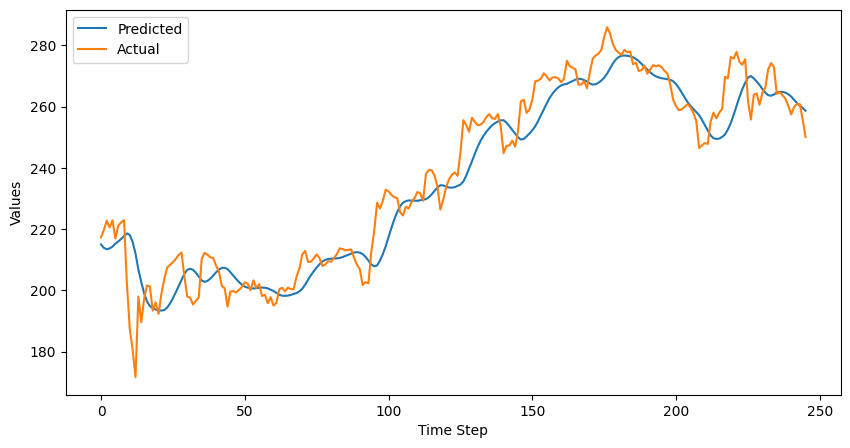

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_pred, label='Predicted')
plt.plot(actual, label='Actual')
plt.ylabel('Values')
plt.xlabel('Time Step')
plt.legend()
plt.show()

# Bidirectional LSTM

In [ ]:
bilstm = Sequential([Input(shape=(window_size, 1)), Bidirectional(LSTM(50)), Dense(1)])
bilstm.summary()
hist_bilstm = compile_and_train(bilstm, "Bidirectional LSTM")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,901 (81.64 KB)

 Trainable params: 20,901 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0214
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0027
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0018
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0016
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0015
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0014
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0012
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0011
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0010
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 9.3857e-04
Bidirectional LSTM trained


# Multilayer LSTM

In [ ]:
multilayer_lstm = Sequential([Input(shape=(window_size, 1)), LSTM(50, return_sequences=True), LSTM(50, return_sequences=True), LSTM(50), Dense(1)])
multilayer_lstm.summary()
hist_multilayer = compile_and_train(multilayer_lstm, "Multilayer LSTM")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 30, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0221
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0027
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0023
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0024
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0022
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0020
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0022
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0017
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0019
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0015
Multilayer LSTM trained


# STATEFUL LSTM

In [ ]:
batch_size = 32
stateful_lstm = Sequential([Input(batch_shape=(batch_size, window_size, 1)), LSTM(50, stateful=True), Dense(1)])
stateful_lstm.compile(optimizer='adam', loss='mse')
stateful_lstm.summary()

train_len = int(len(X_train)) - int(len(X_train) % batch_size)
X_train_s = X_train[:train_len]
y_train_s = y_train[:train_len]

stateful_losses = []

for epoch in range(10):
  print(f"Epoch: {epoch + 1}")
  hist_stateful = stateful_lstm.fit(X_train_s, y_train_s, epochs=1, batch_size=batch_size, shuffle=False, verbose=1)
  stateful_losses.append(hist_stateful.history['loss'][0])

  for layer in stateful_lstm.layers:
    if hasattr(layer, 'reset_states'):
      layer.reset_states()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (32, 50)               │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 1)                │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch: 1
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0094
Epoch: 2
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0112
Epoch: 3
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0081
Epoch: 4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0027
Epoch: 5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.6981e-04
Epoch: 6
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0011    
Epoch: 7
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0012
Epoch: 8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0013
Epoch: 9
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011
Epoch: 10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0011


# Residul LSTM

In [ ]:
input_layer = Input(shape=(window_size,1))
x = LSTM(50, return_sequences=True)(input_layer)
x = LSTM(50)(x)

shortcut = LSTM(50)(input_layer)

output = Add()([x, shortcut])
output = Dense(1)(output)

residual_lstm = tf.keras.Model(input_layer, output)
residual_lstm.summary()
hist_residual = compile_and_train(residual_lstm, "Residul LSTM")


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_14 (LSTM)      │ (None, 30, 50)    │     10,400 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_15 (LSTM)      │ (None, 50)        │     20,200 │ lstm_14[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_16 (LSTM)      │ (None, 50)        │     10,400 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50)        │          0 │ lstm_15[0][0],    │
│                     │                   │            │ lstm_16[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         51 │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,051 (160.36 KB)

 Trainable params: 41,051 (160.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0193
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0018
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0013
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0013
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0012
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0012
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0011
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0011
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0010
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 9.6202e-04
Residul LSTM trained


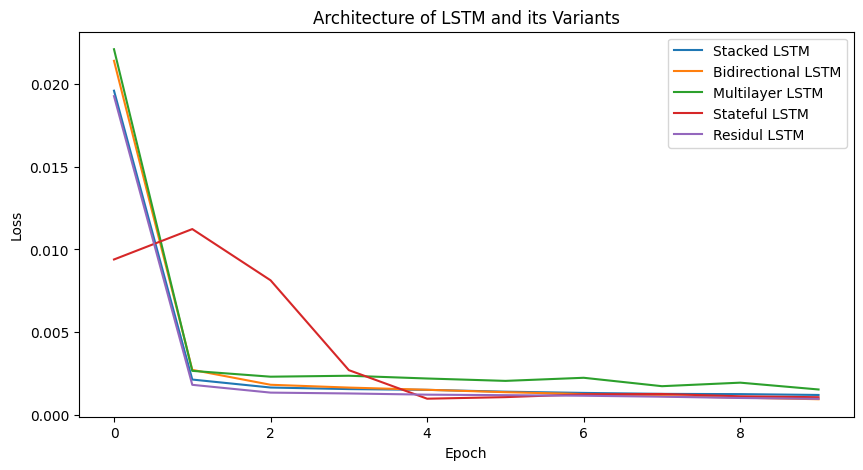

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(hist_stacked.history['loss'], label='Stacked LSTM')
plt.plot(hist_bilstm.history['loss'], label='Bidirectional LSTM')
plt.plot(hist_multilayer.history['loss'], label='Multilayer LSTM')
plt.plot(stateful_losses, label='Stateful LSTM')
plt.plot(hist_residual.history['loss'], label='Residul LSTM')

plt.title('Architecture of LSTM and its Variants')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()